# EMS system test evaluation

This notebook evaluates the four system tests from the EMS demonstration logs. 

The analysis separates three questions.

1. Did the EMS select and apply the intended scenario?
2. Did the selected scenario actually supply the demanded load?
3. Did the EMS reduce grid use during high price periods compared with simple reference operation?

The calculations are kept deliberately simple. The metrics are therefore suitable for discussion in the report, but they should still be interpreted as laboratory demonstration results rather than statistically validated performance results, since each test was only carried out once.

## Imports and constants

This cell imports the required packages and defines the constants used in the evaluation. The logged profile represents 96 intervals of 15 minutes, so one row corresponds to 0.25 hours in the simulated day. Energy is therefore calculated as power in mW multiplied by 0.25 hours, giving mWh.

A small tolerance is used for load tracking. This avoids treating small measurement noise as unmet demand.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

TIME_STEP_H = 0.25
LOAD_TOLERANCE_MW = 5.0
PEM_LOAD_LIMIT_MW = 40.0
HIGH_PRICE_LABEL = "HIGH"
GRID_SCENARIOS = {1, 2, 3}
LOCAL_SCENARIOS = {4, 5, 6}
PV_USE_SCENARIOS = {2, 3, 4}
PEM_LOAD_SCENARIO = 6

scenario_names = {
    1: "S1 Grid to load",
    2: "S2 Grid to load and PV to battery",
    3: "S3 Grid to load and PV to PEM",
    4: "S4 PV to load",
    5: "S5 Battery to load",
    6: "S6 PEM to load",
}

## Locate the test data

This block finds the correct data

In [3]:
def is_main_test_file(path):
    if "scenario_transitions" in path.name:
        return False
    try:
        header = pd.read_csv(path, nrows=0).columns
    except Exception:
        return False
    return "actual_scenario" in header and "demand_mW" in header

def find_data_folder():
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd.parent,
        cwd / "EMS_system_test",
        cwd.parent / "EMS_system_test",
    ]
    for candidate in candidates:
        files = sorted(file for file in candidate.glob("TEST[1-4]_ems_demo_*.csv") if is_main_test_file(file))
        if len(files) >= 4:
            return candidate, files
    raise FileNotFoundError("Could not find TEST1 to TEST4 main CSV files. Place this notebook in analysis_results or in the EMS_system_test folder.")

DATA_DIR, csv_files = find_data_folder()
RESULTS_DIR = DATA_DIR / "analysis_results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Data folder: {DATA_DIR}")
print("Files found:")
for file in csv_files:
    print(f"  {file.name}")

Data folder: c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\data\EMS_system_test
Files found:
  TEST1_ems_demo_20260512_122830.csv
  TEST2_ems_demo_20260512_133302.csv
  TEST3_ems_demo_20260512_142228.csv
  TEST4_ems_demo_20260512_151511.csv


## Load and prepare the data

Each file is loaded into a dictionary where the test name is used as the label. A few additional columns are added to make the later calculations more readable.

The most important derived columns are demand energy, measured load energy, unmet load above the tolerance, and whether the active scenario uses grid supply.

In [ ]:
def test_label_from_file(path):
    return path.name.split("_")[0]

def prepare_test_dataframe(path):
    df = pd.read_csv(path)
    df["test"] = test_label_from_file(path)
    df["scenario_name"] = df["actual_scenario"].map(scenario_names)
    df["delivered_load_mW"] = df["load_power_mW"].clip(lower=0)
    df["demand_energy_mWh"] = df["demand_mW"] * TIME_STEP_H
    df["load_energy_mWh"] = df["delivered_load_mW"] * TIME_STEP_H
    df["unmet_load_mW"] = (df["demand_mW"] - df["delivered_load_mW"] - LOAD_TOLERANCE_MW).clip(lower=0)
    df["unmet_load_mWh"] = df["unmet_load_mW"] * TIME_STEP_H
    df["percentage_demand_supplied"] = 100 * (1 - df["unmet_load_mWh"] / df["demand_energy_mWh"])
    df["absolute_load_error_mW"] = (df["delivered_load_mW"] - df["demand_mW"]).abs()
    df["is_high_price"] = df["price_state"].eq(HIGH_PRICE_LABEL)
    df["uses_grid"] = df["actual_scenario"].isin(GRID_SCENARIOS)
    df["uses_local_source"] = df["actual_scenario"].isin(LOCAL_SCENARIOS)
    df["uses_pv"] = df["actual_scenario"].isin(PV_USE_SCENARIOS)
    df["uses_pem_for_load"] = df["actual_scenario"].eq(PEM_LOAD_SCENARIO)
    df["grid_energy_proxy_mWh"] = np.where(df["uses_grid"], df["demand_energy_mWh"], 0.0)
    df["high_price_grid_energy_proxy_mWh"] = np.where(df["uses_grid"] & df["is_high_price"], df["demand_energy_mWh"], 0.0)
    df["grid_cost_proxy_DKK"] = np.where(df["uses_grid"], df["demand_energy_mWh"] * 1e-6 * df["price_dkk_kwh"], 0.0)
    df["all_grid_cost_proxy_DKK"] = df["demand_energy_mWh"] * 1e-6 * df["price_dkk_kwh"]
    df["pem_output_to_load_mW"] = (-df["pem_power_mW"]).clip(lower=0)
    return df

tests = {test_label_from_file(file): prepare_test_dataframe(file) for file in csv_files}
all_data = pd.concat(tests.values(), ignore_index=True)

display(all_data[["test", "slot", "time_label", "price_state", "demand_mW", "target_scenario", "actual_scenario", "load_power_mW", "virtual_battery_soc_percent", "pem_soc_percent"]].head())

,test,slot,time_label,price_state,demand_mW,target_scenario,actual_scenario,load_power_mW,virtual_battery_soc_percent,pem_soc_percent
0,TEST1,0,00:00,HIGH,34.314081,5,1,-0.041,75.000000,50.087039
1,TEST1,1,00:15,LOW,33.782637,1,5,36.216,74.591039,50.087039
2,TEST1,2,00:30,LOW,33.251193,1,1,37.602,74.591039,50.087039
3,TEST1,3,00:45,LOW,32.719749,1,1,34.666,74.591039,50.087039
4,TEST1,4,01:00,LOW,32.188306,1,1,36.387,74.591039,50.087039


## Metric 1: EMS scenario correctness

This metric evaluates whether the supervisory EMS and the hardware layer agreed on the scenario. It compares the scenario requested by the scheduler with the scenario actually applied by the Arduino.

This is a software and control logic metric. A high value means that the EMS decision path and relay control worked as intended. It does not prove that the physical source supplied the load well.

In [5]:
def count_one_slot_runs(series):
    values = series.to_numpy()
    if len(values) == 0:
        return 0
    run_lengths = []
    current_length = 1
    for i in range(1, len(values)):
        if values[i] == values[i - 1]:
            current_length += 1
        else:
            run_lengths.append(current_length)
            current_length = 1
    run_lengths.append(current_length)
    return sum(length == 1 for length in run_lengths)

def scenario_correctness(df):
    return pd.Series({
        "scenario_match_percent": 100 * (df["target_scenario"] == df["actual_scenario"]).mean(),
        "accepted_percent": 100 * df["scenario_accepted"].fillna(0).astype(bool).mean(),
        "actual_scenario_changes": int(df["actual_scenario"].ne(df["actual_scenario"].shift()).sum() - 1),
        "target_scenario_changes": int(df["target_scenario"].ne(df["target_scenario"].shift()).sum() - 1),
        "one_slot_actual_runs": int(count_one_slot_runs(df["actual_scenario"])),
    })

scenario_correctness_table = all_data.groupby("test").apply(scenario_correctness).round(2)
display(scenario_correctness_table)

C:\Users\matil\AppData\Local\Temp\ipykernel_34560\1234458106.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scenario_correctness_table = all_data.groupby("test").apply(scenario_correctness).round(2)


,scenario_match_percent,accepted_percent,actual_scenario_changes,target_scenario_changes,one_slot_actual_runs
test,,,,,
TEST1,97.92,100.0,6.0,5.0,2.0
TEST2,97.92,100.0,5.0,4.0,1.0
TEST3,96.88,100.0,4.0,3.0,1.0
TEST4,94.79,100.0,8.0,7.0,2.0


## Metric 2: Load supply performance

The EMS objective is not only to select the right scenario. The load must also be supplied. This metric compares the measured load power with the demand profile.

Unmet load is calculated only when the measured delivered load is more than the tolerance below the demand. This gives a simple indication of whether the physical system was able to follow the requested load.

In [19]:
def load_supply_metrics(df):
    demand_energy = df["demand_energy_mWh"].sum()
    unmet_energy = df["unmet_load_mWh"].sum()
    served_percent = 100 * (1 - unmet_energy / demand_energy) if demand_energy > 0 else np.nan
    return pd.Series({
        "demand_energy_mWh": demand_energy,
        "measured_load_energy_mWh": df["load_energy_mWh"].sum(),
        "unmet_load_energy_mWh": unmet_energy,
        "served_demand_percent": served_percent,
        "mean_absolute_load_error_mW": df["absolute_load_error_mW"].mean(),
        "percentage_unmet_load": unmet_energy / demand_energy * 100 if demand_energy > 0 else np.nan,
        "slots_with_unmet_load": int((df["unmet_load_mW"] > 0).sum()),
    })

load_supply_table = all_data.groupby("test").apply(load_supply_metrics).round(2)
display(load_supply_table)

C:\Users\matil\AppData\Local\Temp\ipykernel_34560\3861656621.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  load_supply_table = all_data.groupby("test").apply(load_supply_metrics).round(2)


,demand_energy_mWh,measured_load_energy_mWh,unmet_load_energy_mWh,served_demand_percent,mean_absolute_load_error_mW,percentage_unmet_load,slots_with_unmet_load
test,,,,,,,
TEST1,1004.0,988.97,16.03,98.40,3.28,1.60,10.0
TEST2,1004.0,983.54,30.36,96.98,5.04,3.02,13.0
TEST3,1004.0,923.01,57.21,94.30,5.33,5.70,28.0
TEST4,1004.0,1014.42,9.28,99.08,3.92,0.92,9.0


## Metric 3: Grid use and high price grid use

The control objective is to reduce grid use during high price periods while maintaining load supply. Since the logs do not contain a separate grid power measurement, grid use is estimated from the active scenario.

S1, S2, and S3 are treated as grid to load scenarios. For these scenarios, the grid energy is estimated from the demand profile. This is a proxy, but it fits the relay structure of the setup.

A simple all grid reference is also calculated. In this reference case, the full demand would be supplied by the grid at every time step. The cost numbers are tiny because the setup is in mW, but the relative cost reduction is useful for comparing tests.

In [7]:
def grid_metrics(df):
    total_demand = df["demand_energy_mWh"].sum()
    grid_energy = df["grid_energy_proxy_mWh"].sum()
    high_price_demand = df.loc[df["is_high_price"], "demand_energy_mWh"].sum()
    high_price_grid = df["high_price_grid_energy_proxy_mWh"].sum()
    all_grid_cost = df["all_grid_cost_proxy_DKK"].sum()
    ems_grid_cost = df["grid_cost_proxy_DKK"].sum()
    return pd.Series({
        "grid_energy_proxy_mWh": grid_energy,
        "grid_share_of_demand_percent": 100 * grid_energy / total_demand if total_demand > 0 else np.nan,
        "high_price_grid_energy_proxy_mWh": high_price_grid,
        "high_price_grid_share_percent": 100 * high_price_grid / high_price_demand if high_price_demand > 0 else np.nan,
        "all_grid_cost_proxy_DKK": all_grid_cost,
        "ems_grid_cost_proxy_DKK": ems_grid_cost,
        "cost_reduction_vs_all_grid_percent": 100 * (1 - ems_grid_cost / all_grid_cost) if all_grid_cost > 0 else np.nan,
    })

grid_table = all_data.groupby("test").apply(grid_metrics).round(6)
display(grid_table)

C:\Users\matil\AppData\Local\Temp\ipykernel_34560\3529357643.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grid_table = all_data.groupby("test").apply(grid_metrics).round(6)


,grid_energy_proxy_mWh,grid_share_of_demand_percent,high_price_grid_energy_proxy_mWh,high_price_grid_share_percent,all_grid_cost_proxy_DKK,ems_grid_cost_proxy_DKK,cost_reduction_vs_all_grid_percent
test,,,,,,,
TEST1,853.378356,84.997922,8.578520,100.000000,0.000118,0.000112,4.903490
TEST2,161.370065,16.072730,161.370065,16.072730,0.001049,0.000225,78.561100
TEST3,723.693110,72.081053,723.693110,72.081053,0.001049,0.000762,27.394051
TEST4,389.182830,38.763265,36.308305,5.754405,0.000639,0.000058,90.882860


## Metric 4: Scenario distribution

This table shows how much of the test was spent in each scenario. It is useful because it explains why some tests are dominated by the battery, grid, PV, or PEM.

The energy column uses the demand profile. It therefore describes how much load demand was assigned to each scenario, not the internally measured energy from each component.

In [8]:
scenario_distribution = (
    all_data
    .groupby(["test", "actual_scenario"])
    .agg(
        slots=("slot", "count"),
        simulated_hours=("slot", lambda s: len(s) * TIME_STEP_H),
        demand_energy_mWh=("demand_energy_mWh", "sum"),
        mean_demand_mW=("demand_mW", "mean"),
        mean_load_power_mW=("delivered_load_mW", "mean"),
    )
    .reset_index()
)
scenario_distribution["scenario"] = scenario_distribution["actual_scenario"].map(scenario_names)
scenario_distribution = scenario_distribution[["test", "actual_scenario", "scenario", "slots", "simulated_hours", "demand_energy_mWh", "mean_demand_mW", "mean_load_power_mW"]]
display(scenario_distribution.round(2))

,test,actual_scenario,scenario,slots,simulated_hours,demand_energy_mWh,mean_demand_mW,mean_load_power_mW
0,TEST1,1,S1 Grid to load,45,11.25,410.14,36.46,37.86
1,TEST1,2,S2 Grid to load and PV to battery,21,5.25,198.60,37.83,36.35
2,TEST1,3,S3 Grid to load and PV to PEM,21,5.25,244.63,46.60,45.04
3,TEST1,4,S4 PV to load,8,2.00,142.18,71.09,63.33
4,TEST1,5,S5 Battery to load,1,0.25,8.45,33.78,36.22
5,TEST2,1,S1 Grid to load,13,3.25,161.37,49.65,49.61
6,TEST2,4,S4 PV to load,50,12.50,585.41,46.83,44.36
7,TEST2,5,S5 Battery to load,29,7.25,221.13,30.50,35.35
8,TEST2,6,S6 PEM to load,4,1.00,36.09,36.09,11.55
9,TEST3,1,S1 Grid to load,56,14.00,723.69,51.69,51.17


## Metric 5: PV use

This metric evaluates how often available PV was used by the EMS. A row is counted as PV used when the active scenario is S2, S3, or S4.

This is a simple scenario based metric. It does not evaluate optimal PV use, because the current relay design only allows one main PV path at a time.

In [9]:
def pv_metrics(df):
    pv_available_slots = int(df["pv_available"].sum())
    pv_used_slots = int((df["pv_available"] & df["uses_pv"]).sum())
    measured_pv_energy = df["pv_power_mW"].clip(lower=0).sum() * TIME_STEP_H
    return pd.Series({
        "pv_available_slots": pv_available_slots,
        "pv_used_when_available_slots": pv_used_slots,
        "pv_used_when_available_percent": 100 * pv_used_slots / pv_available_slots if pv_available_slots > 0 else np.nan,
        "measured_positive_pv_energy_mWh": measured_pv_energy,
    })

pv_table = all_data.groupby("test").apply(pv_metrics).round(2)
display(pv_table)

C:\Users\matil\AppData\Local\Temp\ipykernel_34560\2179157704.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pv_table = all_data.groupby("test").apply(pv_metrics).round(2)


,pv_available_slots,pv_used_when_available_slots,pv_used_when_available_percent,measured_positive_pv_energy_mWh
test,,,,
TEST1,50.0,50.0,100.0,2618.95
TEST2,50.0,50.0,100.0,626.87
TEST3,0.0,0.0,NaN,3.85
TEST4,50.0,50.0,100.0,935.37


## Metric 6: PEM load supply performance

This metric focuses only on S6, where the PEM cell is supposed to supply the load. It is the most important diagnostic metric for the reversible PEM cell as a practical backup source.

The table compares demand with measured load power and with the PEM output power. PEM output power is calculated as the negative PEM power during discharge, clipped at zero.

In [10]:
def pem_metrics(df):
    s6 = df[df["uses_pem_for_load"]].copy()
    if s6.empty:
        return pd.Series({
            "s6_slots": 0,
            "s6_demand_energy_mWh": 0.0,
            "s6_unmet_load_energy_mWh": 0.0,
            "s6_served_demand_percent": np.nan,
            "s6_mean_load_mismatch_mW": np.nan,
            "s6_mean_pem_output_mW": np.nan,
            "s6_mean_demand_mW": np.nan,
            "s6_slots_above_pem_limit": 0,
        })
    demand_energy = s6["demand_energy_mWh"].sum()
    unmet_energy = s6["unmet_load_mWh"].sum()
    return pd.Series({
        "s6_slots": int(len(s6)),
        "s6_demand_energy_mWh": demand_energy,
        "s6_unmet_load_energy_mWh": unmet_energy,
        "s6_served_demand_percent": 100 * (1 - unmet_energy / demand_energy) if demand_energy > 0 else np.nan,
        "s6_mean_load_mismatch_mW": (s6["demand_mW"] - s6["delivered_load_mW"]).mean(),
        "s6_mean_pem_output_mW": s6["pem_output_to_load_mW"].mean(),
        "s6_mean_demand_mW": s6["demand_mW"].mean(),
        "s6_slots_above_pem_limit": int((s6["demand_mW"] > PEM_LOAD_LIMIT_MW).sum()),
    })

pem_table = all_data.groupby("test").apply(pem_metrics).round(2)
display(pem_table)

C:\Users\matil\AppData\Local\Temp\ipykernel_34560\623189626.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pem_table = all_data.groupby("test").apply(pem_metrics).round(2)


,s6_slots,s6_demand_energy_mWh,s6_unmet_load_energy_mWh,s6_served_demand_percent,s6_mean_load_mismatch_mW,s6_mean_pem_output_mW,s6_mean_demand_mW,s6_slots_above_pem_limit
test,,,,,,,,
TEST1,0.0,0.00,0.00,NaN,NaN,NaN,NaN,0.0
TEST2,4.0,36.09,19.54,45.87,24.54,13.63,36.09,0.0
TEST3,35.0,239.54,47.76,80.06,8.88,22.78,27.38,1.0
TEST4,0.0,0.00,0.00,NaN,NaN,NaN,NaN,0.0


## Metric 7: Storage state change

This metric shows how the virtual battery state and the estimated hydrogen state changed during each test. It is useful for checking whether the EMS used or charged the intended storage component.

The hydrogen values are estimates based on the EMS model. They are not direct measurements of the physical gas volume.

In [11]:
def storage_metrics(df):
    first = df.iloc[0]
    last = df.iloc[-1]
    return pd.Series({
        "battery_soc_start_percent": first["virtual_battery_soc_percent"],
        "battery_soc_end_percent": last["virtual_battery_soc_percent"],
        "battery_soc_change_percent_point": last["virtual_battery_soc_percent"] - first["virtual_battery_soc_percent"],
        "pem_soc_start_percent": first["pem_soc_percent"],
        "pem_soc_end_percent": last["pem_soc_percent"],
        "pem_soc_change_percent_point": last["pem_soc_percent"] - first["pem_soc_percent"],
        "h2_start_mL": first["h2_volume_mL"],
        "h2_end_mL": last["h2_volume_mL"],
        "h2_change_mL": last["h2_volume_mL"] - first["h2_volume_mL"],
    })

storage_table = all_data.groupby("test").apply(storage_metrics).round(2)
display(storage_table)

C:\Users\matil\AppData\Local\Temp\ipykernel_34560\2361663326.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  storage_table = all_data.groupby("test").apply(storage_metrics).round(2)


,battery_soc_start_percent,battery_soc_end_percent,battery_soc_change_percent_point,pem_soc_start_percent,pem_soc_end_percent,pem_soc_change_percent_point,h2_start_mL,h2_end_mL,h2_change_mL
test,,,,,,,,,
TEST1,75.0,90.05,15.05,50.09,100.00,49.91,11.61,15.60,3.99
TEST2,20.0,9.97,-10.03,100.00,96.96,-3.04,15.60,15.36,-0.24
TEST3,12.0,9.99,-2.01,80.02,24.83,-55.19,14.00,9.59,-4.42
TEST4,90.0,77.44,-12.56,50.02,72.61,22.60,11.60,13.41,1.81


## Optional physical hydrogen reading check

The CSV files contain the EMS hydrogen estimate, but not the manual reading from the gas cylinders. If manual start and end readings are available from lab notes, they can be inserted in the dictionary below.

Leave a value as `None` if no manual reading is available. The output table will then show the difference between estimated and manually observed hydrogen volume.

In [ ]:
physical_h2_readings_mL = {
    "TEST1": {"start": 4, "end": 7},
    "TEST2": {"start": 8, "end": 7.65},
    "TEST3": {"start": 6.40, "end": 2},
    "TEST4": {"start": 4, "end": 4.2},
}

rows = []
for test, df in tests.items():
    readings = physical_h2_readings_mL.get(test, {})
    estimated_start = df.iloc[0]["h2_volume_mL"]
    estimated_end = df.iloc[-1]["h2_volume_mL"]
    physical_start = readings.get("start")
    physical_end = readings.get("end")
    rows.append({
        "test": test,
        "estimated_start_mL": estimated_start,
        "physical_start_mL": physical_start,
        "start_error_mL": None if physical_start is None else estimated_start - physical_start,
        "estimated_end_mL": estimated_end,
        "physical_end_mL": physical_end,
        "end_error_mL": None if physical_end is None else estimated_end - physical_end,
    })

physical_h2_table = pd.DataFrame(rows).round(2)
display(physical_h2_table)

,test,estimated_start_mL,physical_start_mL,start_error_mL,estimated_end_mL,physical_end_mL,end_error_mL
0,TEST1,11.61,None,None,15.60,None,None
1,TEST2,15.60,None,None,15.36,None,None
2,TEST3,14.00,None,None,9.59,None,None
3,TEST4,11.60,None,None,13.41,None,None


## Combined evaluation table

This table combines the most useful metrics into one compact overview. It is intended to support the results discussion directly.

The most important columns are scenario match, unmet load, high price grid use, cost reduction compared with an all grid reference, number of scenario changes, PEM load supply performance, and storage state changes.

In [13]:
combined_table = (
    scenario_correctness_table
    .join(load_supply_table)
    .join(grid_table)
    .join(pv_table)
    .join(pem_table)
    .join(storage_table)
)

main_columns = [
    "scenario_match_percent",
    "actual_scenario_changes",
    "one_slot_actual_runs",
    "served_demand_percent",
    "unmet_load_energy_mWh",
    "grid_share_of_demand_percent",
    "high_price_grid_share_percent",
    "cost_reduction_vs_all_grid_percent",
    "pv_used_when_available_percent",
    "s6_slots",
    "s6_served_demand_percent",
    "s6_mean_pem_output_mW",
    "s6_mean_demand_mW",
    "battery_soc_change_percent_point",
    "pem_soc_change_percent_point",
    "h2_change_mL",
]

summary_for_report = combined_table[main_columns].round(2)
display(summary_for_report)

,scenario_match_percent,actual_scenario_changes,one_slot_actual_runs,served_demand_percent,unmet_load_energy_mWh,grid_share_of_demand_percent,high_price_grid_share_percent,cost_reduction_vs_all_grid_percent,pv_used_when_available_percent,s6_slots,s6_served_demand_percent,s6_mean_pem_output_mW,s6_mean_demand_mW,battery_soc_change_percent_point,pem_soc_change_percent_point,h2_change_mL
test,,,,,,,,,,,,,,,,
TEST1,97.92,6.0,2.0,98.40,16.03,85.00,100.00,4.90,100.0,0.0,NaN,NaN,NaN,15.05,49.91,3.99
TEST2,97.92,5.0,1.0,96.98,30.36,16.07,16.07,78.56,100.0,4.0,45.87,13.63,36.09,-10.03,-3.04,-0.24
TEST3,96.88,4.0,1.0,94.30,57.21,72.08,72.08,27.39,NaN,35.0,80.06,22.78,27.38,-2.01,-55.19,-4.42
TEST4,94.79,8.0,2.0,99.08,9.28,38.76,5.75,90.88,100.0,0.0,NaN,NaN,NaN,-12.56,22.60,1.81


## Simple plots for interpretation

The following plots give a fast visual comparison of the four tests. They are not meant to replace the timeline plots, but to make the evaluation metrics easier to compare.

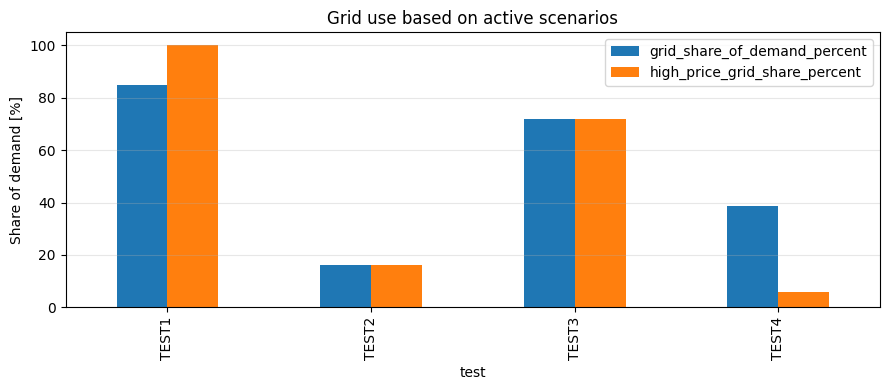

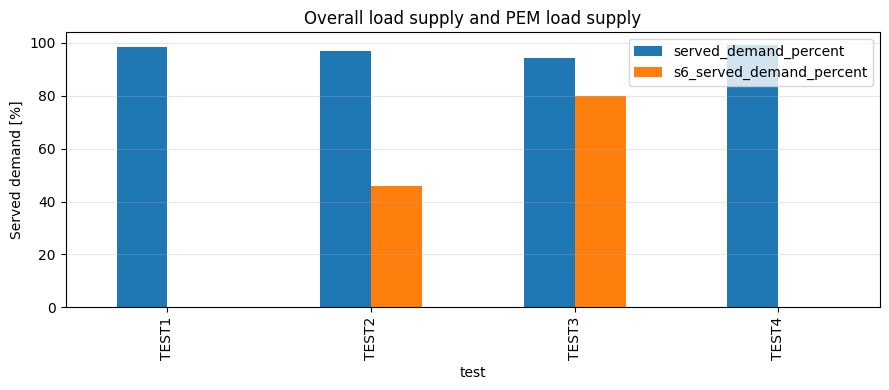

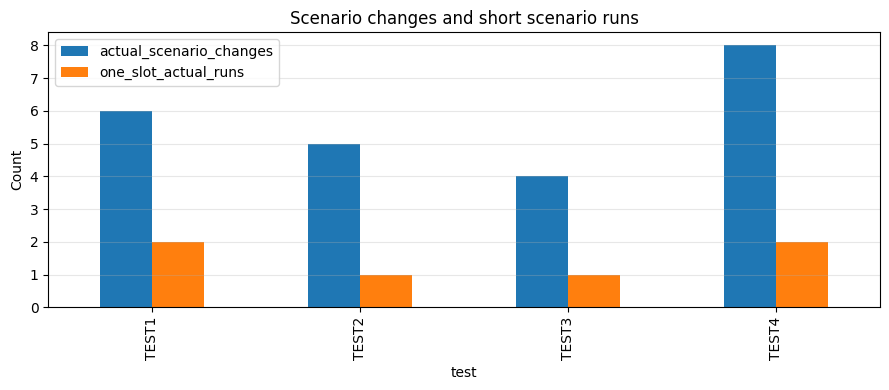

In [14]:
plot_table = summary_for_report.copy()

ax = plot_table[["grid_share_of_demand_percent", "high_price_grid_share_percent"]].plot(kind="bar", figsize=(9, 4))
ax.set_ylabel("Share of demand [%]")
ax.set_title("Grid use based on active scenarios")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

ax = plot_table[["served_demand_percent", "s6_served_demand_percent"]].plot(kind="bar", figsize=(9, 4))
ax.set_ylabel("Served demand [%]")
ax.set_title("Overall load supply and PEM load supply")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

ax = plot_table[["actual_scenario_changes", "one_slot_actual_runs"]].plot(kind="bar", figsize=(9, 4))
ax.set_ylabel("Count")
ax.set_title("Scenario changes and short scenario runs")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Detailed S6 plot

This plot is only shown for tests where S6 occurs. It compares demand, measured load power, and PEM output power during PEM load supply. It is useful for showing whether the PEM scenario was physically successful, not only logically selected.

TEST1: no S6 operation


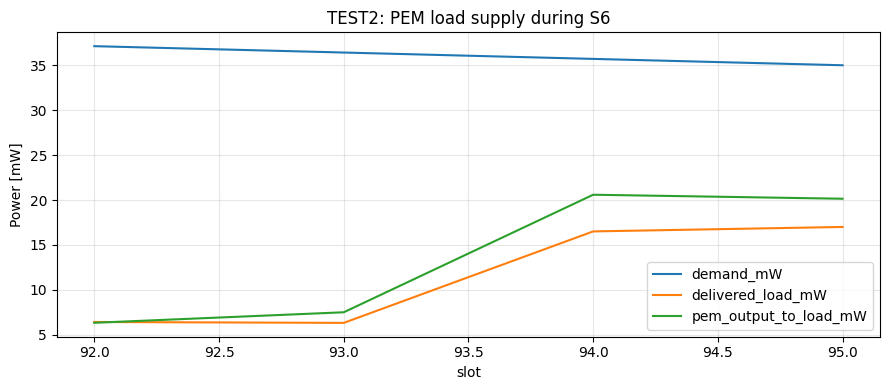

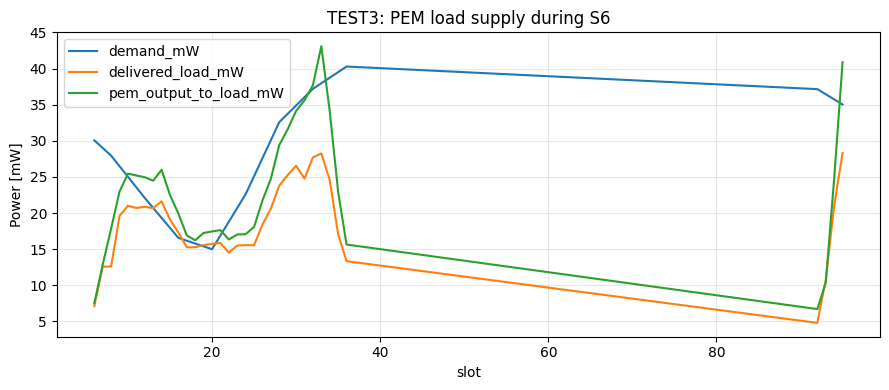

TEST4: no S6 operation


In [15]:
for test, df in tests.items():
    s6 = df[df["uses_pem_for_load"]].copy()
    if s6.empty:
        print(f"{test}: no S6 operation")
        continue
    ax = s6.plot(x="slot", y=["demand_mW", "delivered_load_mW", "pem_output_to_load_mW"], figsize=(9, 4))
    ax.set_ylabel("Power [mW]")
    ax.set_title(f"{test}: PEM load supply during S6")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Save results

The final tables are saved to the `analysis_results` folder, so they can be inserted into the report or used for later plotting.

In [16]:
summary_for_report.to_csv(RESULTS_DIR / "ems_test_summary_metrics.csv")
scenario_distribution.to_csv(RESULTS_DIR / "ems_test_scenario_distribution.csv", index=False)
physical_h2_table.to_csv(RESULTS_DIR / "ems_test_optional_hydrogen_check.csv", index=False)

print("Saved files:")
print(RESULTS_DIR / "ems_test_summary_metrics.csv")
print(RESULTS_DIR / "ems_test_scenario_distribution.csv")
print(RESULTS_DIR / "ems_test_optional_hydrogen_check.csv")

Saved files:
c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\data\EMS_system_test\analysis_results\ems_test_summary_metrics.csv
c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\data\EMS_system_test\analysis_results\ems_test_scenario_distribution.csv
c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\data\EMS_system_test\analysis_results\ems_test_optional_hydrogen_check.csv


## How to use the results in the thesis

Use the scenario correctness metric to state that the implemented EMS logic generally selected the expected relay scenario.

Use the load supply and S6 metrics to show that correct EMS decisions did not always result in good physical operation, especially during PEM load supply.

Use the grid and high price grid metrics to discuss whether the EMS fulfilled its operating objective of reducing grid use during high price periods.

Use the storage metrics to show whether the battery and PEM states evolved in the expected direction during charging and discharging tests.

The strongest interpretation is that the EMS was successful as a control logic demonstration, but only partly successful as a physical energy management system, because the PEM cell and the low voltage load interface limited actual load supply.